# GNSS-IR: Lomb-Scargle of SNR vs Elevation

Fetches SNR observations and satellite elevation/azimuth from api.earthscope.org,
then computes the Lomb-Scargle periodogram of detrended SNR as a function of sin(elevation).
The dominant frequency maps to a reflector height: **H = λ · f_peak / 2**

Run `es login` in a terminal before using this notebook if you haven't authenticated yet.

In [35]:
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from earthscope_sdk import EarthScopeClient
from earthscope_sdk.client.data_access.models import GeodeticCoordinate, FloatFilter
from scipy.signal import lombscargle

client = EarthScopeClient()

## Parameters

In [46]:
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

STATION = "P04000USA"  # IGS 9-char station ID
ref_pt = GeodeticCoordinate(
    latitude=38.0714982807,
    longitude=-102.6869823081,
    height=1102.64837,
    label=STATION,
)

# Data retrieval settings
SAMPLE_INTERVAL = dt.timedelta(seconds=15)
OBS_CODE = "1C"  # RINEX obs code; 1C = L1 C/A
SYSTEM = "G"  # G=GPS, R=GLONASS, E=Galileo, C=BeiDou

DATE = dt.date(2024, 1, 1)
start = dt.datetime(DATE.year, DATE.month, DATE.day, tzinfo=dt.timezone.utc)
end = start + dt.timedelta(days=1)

# GNSS-IR analysis settings
ELEV_MIN = 5.0  # degrees — exclude near-horizon noise
ELEV_MAX = 30.0  # degrees — standard GNSS-IR window
POLY_DEG = 2  # polynomial order for SNR detrending

# L1 GPS wavelength; change for other signals
# L1=0.1903, L2=0.2442, L5=0.2548  (metres)
WAVELENGTH = 0.1903

# Lomb-Scargle frequency grid (reflector height in metres)
H_MIN, H_MAX, H_STEP = 0.1, 10.0, 0.01

print(ref_pt)

latitude=38.0714982807 longitude=-102.6869823081 height=1102.64837 label='P04000USA'


## 1 · Fetch data from EarthScope

GPS satellites broadcast a signal that reaches the antenna two ways: directly, and bounced off the ground nearby. These two paths interfere with each other, and that interference shows up as ripples in the signal-to-noise ratio (SNR) as the satellite moves across the sky. To measure this we need two things for the same time period: the raw SNR values, and the satellite's elevation/azimuth angles (its position in the sky). This section downloads both from EarthScope's API.

In [37]:
print(f"Fetching SNR observations at {SAMPLE_INTERVAL} ...")
obs_df = client.data.gnss_observations(
    start_datetime=start,
    end_datetime=end,
    station_name=STATION,
    system=[SYSTEM],
    field="snr",
    obs_code=OBS_CODE,
    sample_interval=SAMPLE_INTERVAL,
    session_name="A",
).fetch().to_pandas()

print(f"  {len(obs_df):,} rows — columns: {obs_df.columns.tolist()}")
obs_df.head()

Fetching SNR observations at 0:00:15 ...
  59,380 rows — columns: ['timestamp', 'satellite', 'obs_code', 'snr', 'system', 'igs']


,timestamp,satellite,obs_code,snr,system,igs
0,2024-01-01 13:24:15+00:00,23,1C,36.299999,G,P04000USA
1,2024-01-01 13:24:15+00:00,25,1C,39.900002,G,P04000USA
2,2024-01-01 13:24:15+00:00,26,1C,33.200001,G,P04000USA
3,2024-01-01 13:24:15+00:00,28,1C,49.000000,G,P04000USA
4,2024-01-01 13:24:15+00:00,31,1C,48.299999,G,P04000USA


In [38]:
print("Fetching satellite elevations/azimuths ...")
eph_df = client.data.gnss_ephemeris_positions(
    start_datetime=start,
    end_datetime=end,
    system=[SYSTEM],
    field=["elevation", "azimuth"],
    reference_point=ref_pt,
    elevation_filter=FloatFilter(min=ELEV_MIN - 2),
    sample_interval=SAMPLE_INTERVAL,
).fetch().to_pandas()

print(f"  {len(eph_df):,} rows — columns: {eph_df.columns.tolist()}")
eph_df.head()

Fetching satellite elevations/azimuths ...
  56,656 rows — columns: ['timestamp', 'system', 'satellite', 'elevation', 'azimuth', 'label']


,timestamp,system,satellite,elevation,azimuth,label
0,2024-01-01 02:58:00+00:00,G,5,3.085801,186.348633,P04000USA
1,2024-01-01 02:58:15+00:00,G,5,3.180655,186.322998,P04000USA
2,2024-01-01 02:58:30+00:00,G,5,3.275611,186.297455,P04000USA
3,2024-01-01 02:58:45+00:00,G,5,3.370669,186.272018,P04000USA
4,2024-01-01 02:59:00+00:00,G,5,3.465827,186.246674,P04000USA


## 2 · Merge and explore

The SNR data and the satellite position data come from separate queries, so they need to be lined up by timestamp and satellite. This section joins the two tables so every SNR reading is paired with the sky position of the satellite that produced it.

In [39]:
# igs (obs) and label (eph) are both the IGS station identifier — join on them
# to prevent cross-station contamination when processing multiple stations.
merged = obs_df.merge(
    eph_df.rename(columns={"label": "igs"}),
    on=["timestamp", "system", "satellite", "igs"],
    how="inner",
).sort_values(["timestamp", "system", "satellite"]).reset_index(drop=True)

print(f"Merged rows: {len(merged):,}")
print(f"Unique satellites: {sorted(merged['satellite'].unique())}")
merged.head()

Merged rows: 56,126
Unique satellites: [np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32)]


,timestamp,satellite,obs_code,snr,system,igs,elevation,azimuth
0,2024-01-01 00:00:00+00:00,2,1C,39.500000,G,P04000USA,15.940251,40.397980
1,2024-01-01 00:00:00+00:00,3,1C,34.400002,G,P04000USA,4.015063,86.772240
2,2024-01-01 00:00:00+00:00,6,1C,41.299999,G,P04000USA,22.515110,182.666428
3,2024-01-01 00:00:00+00:00,7,1C,39.299999,G,P04000USA,7.954891,152.924988
4,2024-01-01 00:00:00+00:00,13,1C,42.000000,G,P04000USA,23.056396,242.976196


## 3 · Split into arcs and detrend SNR

A satellite doesn't stay in one spot — it rises, peaks, and sets. Each continuous rise or fall is called an "arc," and GNSS-IR analyzes one arc at a time. This section cuts the data into arcs (splitting on data gaps or when the satellite changes from rising to setting) and then removes the slow, smooth part of the SNR curve (caused by the satellite's own antenna pattern, not reflections). What's left after this "detrending" is just the ripple caused by ground reflections — the signal we actually want to measure.

In [40]:
def split_arcs(df, gap_threshold_min=10):
    """Split a single-satellite DataFrame into rising/setting arcs.
    Vectorized: uses diff() to find time gaps and elevation reversals.
    """
    df = df.sort_values("timestamp").reset_index(drop=True)

    time_diff  = df["timestamp"].diff().dt.total_seconds().fillna(0)
    time_gap   = time_diff > gap_threshold_min * 60

    elev_diff  = df["elevation"].diff()
    # Sign change in consecutive elevation differences → arc apex
    elev_rev   = ((elev_diff * elev_diff.shift(1)) < 0).fillna(False)

    arc_id = (time_gap | elev_rev).cumsum()
    return [g.reset_index(drop=True) for _, g in df.groupby(arc_id) if len(g) >= 10]


def detrend_snr(arc, poly_deg=POLY_DEG):
    """Remove a polynomial trend from SNR using sin(elevation) as x.
    Returns the arc DataFrame with a 'snr_detrend' column added.
    """
    x = np.sin(np.radians(arc["elevation"].values))
    y = arc["snr"].values
    valid = np.isfinite(y)
    if valid.sum() < poly_deg + 2:
        return None
    if arc["elevation"].max() - arc["elevation"].min() < 2.0:
        return None  # too short an arc to detrend reliably
    coeffs = np.polyfit(x[valid], y[valid], poly_deg)
    trend = np.polyval(coeffs, x)
    arc = arc.copy()
    arc["snr_detrend"] = y - trend
    arc["sin_elev"] = x
    return arc

filtered = merged[
    (merged["obs_code"] == OBS_CODE) &
    merged["snr"].notna() &
    (merged["elevation"] >= ELEV_MIN) &
    (merged["elevation"] <= ELEV_MAX)
].copy()

all_arcs = []
for sat, grp in filtered.groupby("satellite"):
    for arc in split_arcs(grp):
        arc = detrend_snr(arc)
        if arc is not None:
            arc["satellite"] = sat
            all_arcs.append(arc)

print(f"Found {len(all_arcs)} arcs across {filtered['satellite'].nunique()} satellites")

Found 90 arcs across 30 satellites


## 4 · Lomb-Scargle and reflector height

The ripple frequency in the detrended SNR is directly related to how high the antenna sits above the reflecting surface: H = wavelength × frequency / 2. Because the data points aren't evenly spaced (elevation angle doesn't increase at a constant rate), a regular FFT won't work — instead this section uses the Lomb-Scargle periodogram, which handles unevenly spaced data. For each arc, it scans a range of candidate heights and picks the one with the strongest matching ripple as that arc's reflector height estimate.

In [41]:
# Frequency grid: convert from reflector height (m) to LS angular frequency
# The relationship is: sin(elev) oscillates at f = 2H/λ cycles per unit of sin(elev)
# scipy.signal.lombscargle expects angular frequency ω = 2πf
heights = np.arange(H_MIN, H_MAX, H_STEP)
freqs   = 2 * heights / WAVELENGTH
omegas  = 2 * np.pi * freqs


def lomb_scargle_arc(arc):
    """Run LS on a detrended arc. Returns (heights, power, peak_height, peak_power)."""
    x = arc["sin_elev"].values
    y = arc["snr_detrend"].values
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 10:
        return None
    # Normalize y for a meaningful power spectrum
    y_norm = (y[valid] - y[valid].mean())
    pgram = lombscargle(x[valid], y_norm, omegas, normalize=True)
    peak_idx = np.argmax(pgram)
    return heights, pgram, heights[peak_idx], pgram[peak_idx]


results = []
for arc in all_arcs:
    out = lomb_scargle_arc(arc)
    if out is None:
        continue
    _, _, peak_h, peak_pwr = out
    results.append({
        "satellite": arc["satellite"].iloc[0],
        "azimuth_mean": arc["azimuth"].mean(),
        "elev_mean": arc["elevation"].mean(),
        "t_center": arc["timestamp"].mean(),
        "peak_height": peak_h,
        "peak_power": peak_pwr,
        "n_pts": len(arc),
        "arc": arc,
        "ls": out,
    })

res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("arc", "ls")} for r in results])
print(f"Processed {len(results)} arcs")
print(res_df.sort_values("peak_power", ascending=False).head(10).to_string(index=False))

Processed 90 arcs
 satellite  azimuth_mean  elev_mean                         t_center  peak_height  peak_power  n_pts
        12     44.955593   7.947167 2024-01-01 13:36:52.500000+00:00         1.75    0.839745    194
         2     38.232491  10.534491        2024-01-01 00:16:00+00:00         1.87    0.805936    129
         3     44.032131  10.235023 2024-01-01 01:43:22.740000+00:00         1.77    0.783705    250
        15    271.294708   7.403555 2024-01-01 00:12:11.597000+00:00         1.78    0.759052     97
        12     65.197861   7.964143 2024-01-01 12:47:40.477000+00:00         2.02    0.733207    199
         3     70.549835  10.274960 2024-01-01 00:39:50.588000+00:00         1.81    0.681402    255
        16    286.456848  10.548754 2024-01-01 08:43:01.806000+00:00         1.92    0.594086    274
        20    314.124054   8.004113 2024-01-01 18:58:10.625000+00:00         2.25    0.589146    192
        20    294.011627   7.892585        2024-01-01 19:48:15+00:00     

## 5 · Visualize: SNR arcs + LS periodograms

This section plots the strongest arcs (highest periodogram peaks) as a sanity check: one panel shows the raw vs. detrended SNR curve, and the other shows the periodogram with the winning height marked. If the detrending and height-picking are working correctly, these plots should show a clean oscillation and a sharp periodogram peak.

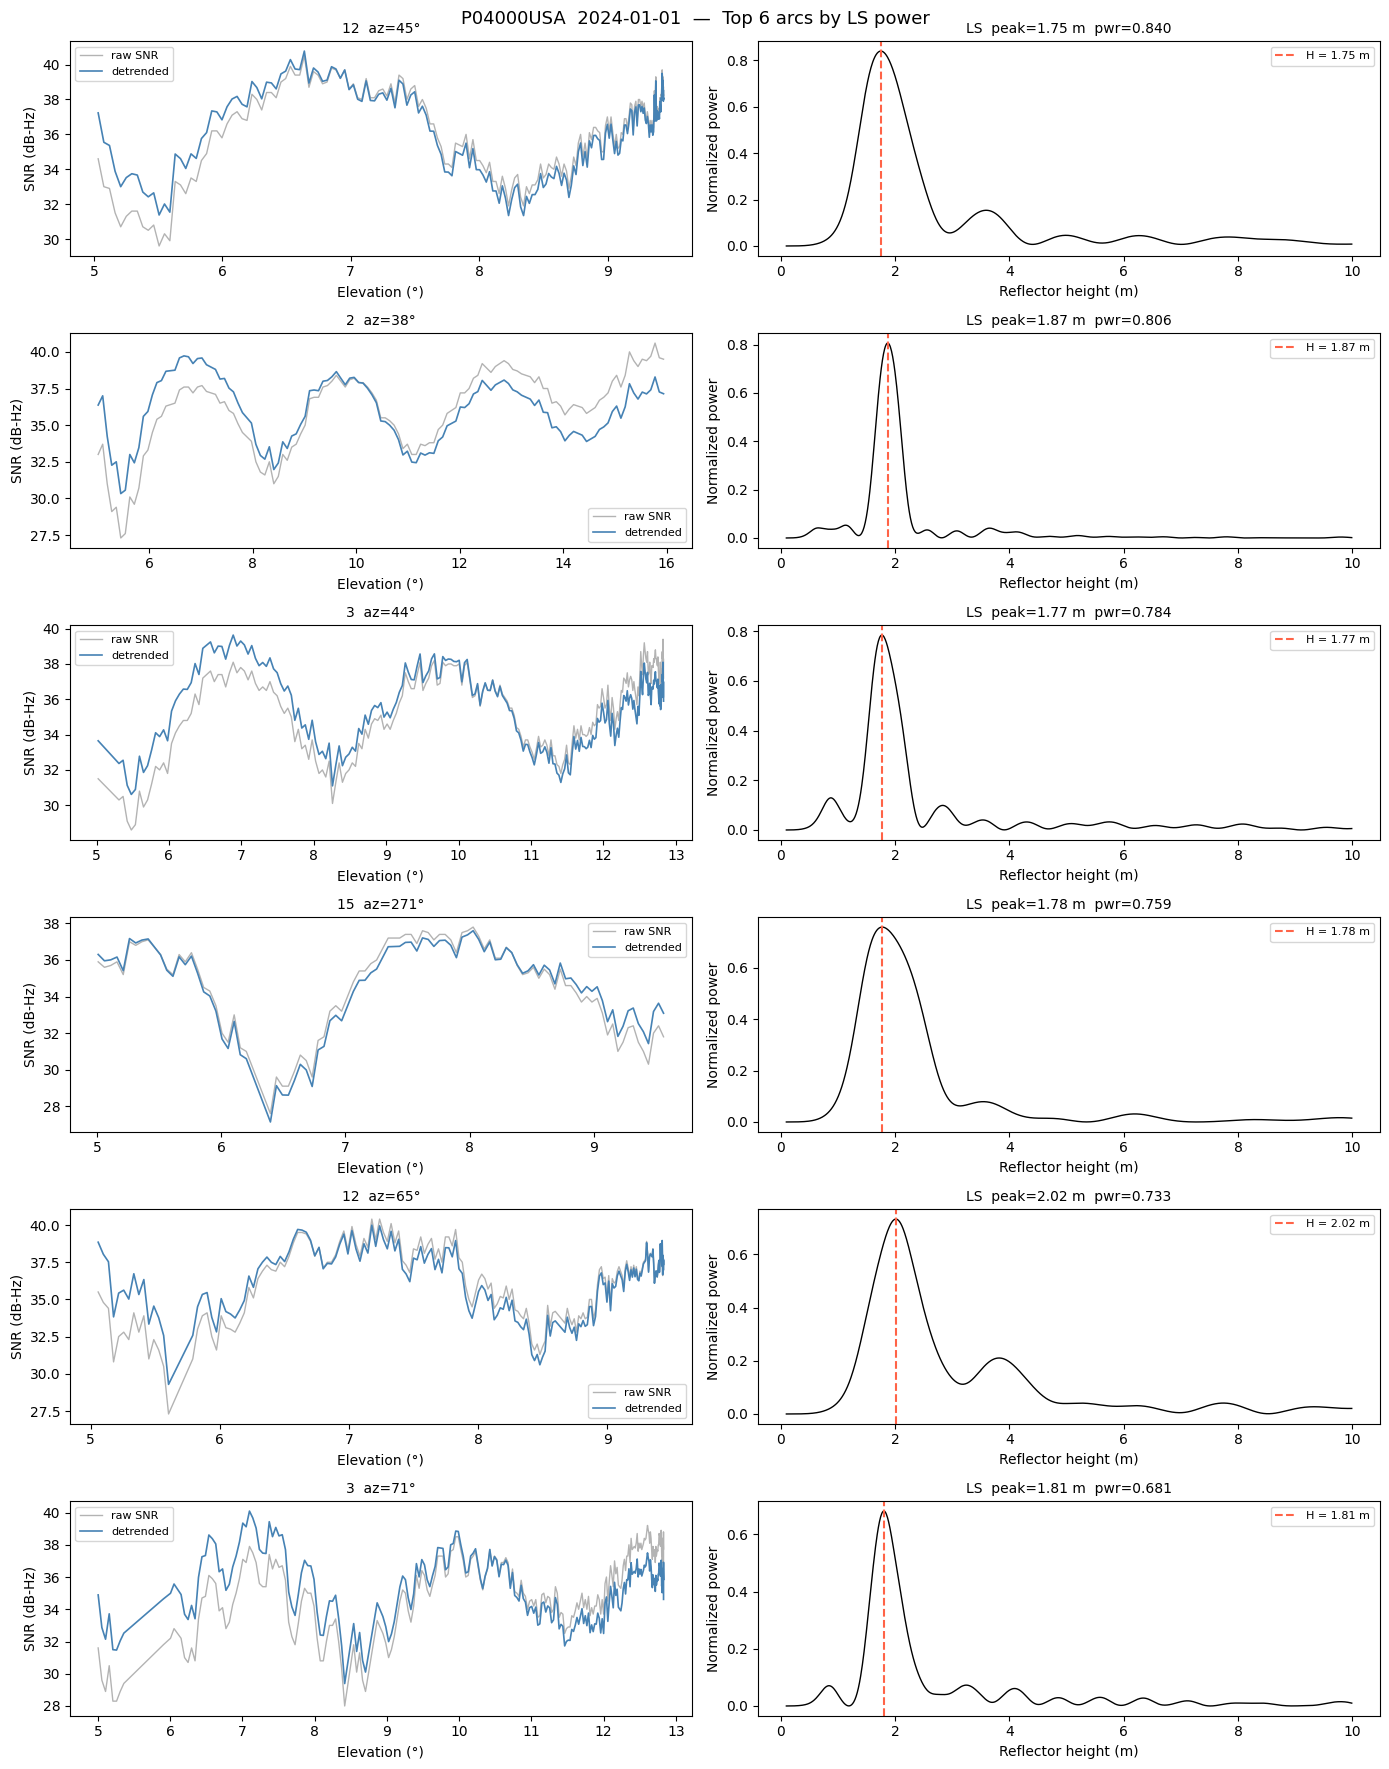

In [42]:
# Show the top-N arcs by LS peak power
top_n = 6
top_results = sorted(results, key=lambda r: r["peak_power"], reverse=True)[:top_n]

fig, axes = plt.subplots(top_n, 2, figsize=(14, top_n * 3))
fig.suptitle(f"{STATION}  {DATE}  —  Top {top_n} arcs by LS power", fontsize=13)

for i, r in enumerate(top_results):
    arc = r["arc"]
    hs, pgram, peak_h, peak_pwr = r["ls"]
    sat = r["satellite"]
    az  = r["azimuth_mean"]

    ax_snr = axes[i, 0]
    ax_ls  = axes[i, 1]

    # Raw + detrended SNR
    ax_snr.plot(arc["elevation"], arc["snr"], "0.7", lw=1, label="raw SNR")
    ax_snr.plot(arc["elevation"], arc["snr_detrend"] + arc["snr"].mean(),
                "steelblue", lw=1.2, label="detrended")
    ax_snr.set_xlabel("Elevation (°)")
    ax_snr.set_ylabel("SNR (dB-Hz)")
    ax_snr.set_title(f"{sat}  az={az:.0f}°", fontsize=10)
    ax_snr.legend(fontsize=8)

    # Lomb-Scargle
    ax_ls.plot(hs, pgram, "k", lw=1)
    ax_ls.axvline(peak_h, color="tomato", lw=1.5, ls="--",
                  label=f"H = {peak_h:.2f} m")
    ax_ls.set_xlabel("Reflector height (m)")
    ax_ls.set_ylabel("Normalized power")
    ax_ls.set_title(f"LS  peak={peak_h:.2f} m  pwr={peak_pwr:.3f}", fontsize=10)
    ax_ls.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"{STATION}_{DATE}_snr_arcs_ls.png", dpi=200, bbox_inches="tight")
plt.show()

## 6 · Reflector height vs azimuth (polar plot)

Different satellites pass overhead in different compass directions (azimuths), so each arc "looks" at the ground in a different direction from the antenna. If the ground isn't perfectly flat and level around the station, the measured reflector height will vary by direction. This section plots height (radius) against azimuth (angle) on a polar plot to reveal that directional pattern.

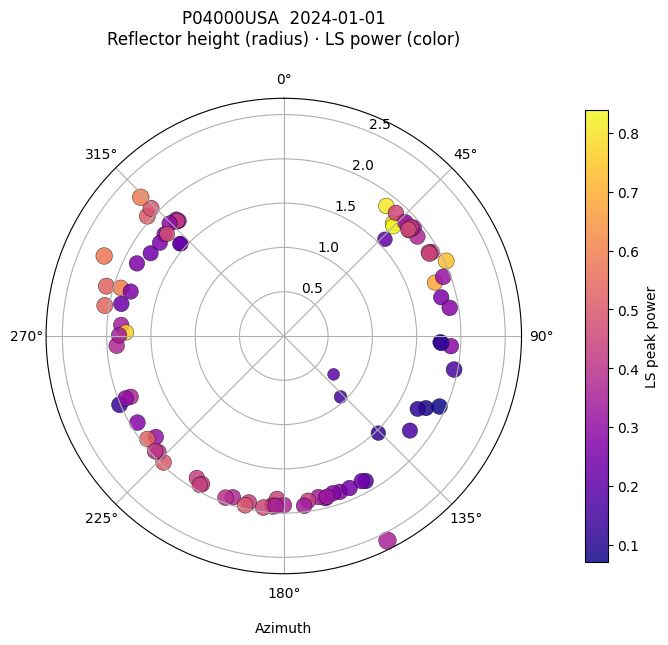

In [43]:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(7, 7))

az_rad = np.radians(res_df["azimuth_mean"].values)
h_vals = res_df["peak_height"].values
pwr    = res_df["peak_power"].values

sc = ax.scatter(az_rad, h_vals, c=pwr, s=40 + 120 * h_vals / h_vals.max(),
                cmap="plasma", vmin=pwr.min(), vmax=pwr.max(),
                alpha=0.85, edgecolors="k", lw=0.3)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xlabel("Azimuth", labelpad=15)
cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("LS peak power")
ax.set_title(f"{STATION}  {DATE}\nReflector height (radius) · LS power (color)", pad=20)
plt.tight_layout()
fig.savefig(FIG_DIR / f"{STATION}_{DATE}_polar.png", dpi=200, bbox_inches="tight")
plt.show()

## 7 · Time series (multi-day skeleton)

Extend this to loop over dates and accumulate `res_df` rows.

This section groups arcs from the single day into four compass sectors (N, E, S, W) and plots reflector height over the course of the day. It's a template meant to be extended to many days, since tracking height over time is how GNSS-IR detects real changes at the surface, like snow piling up or water rising.

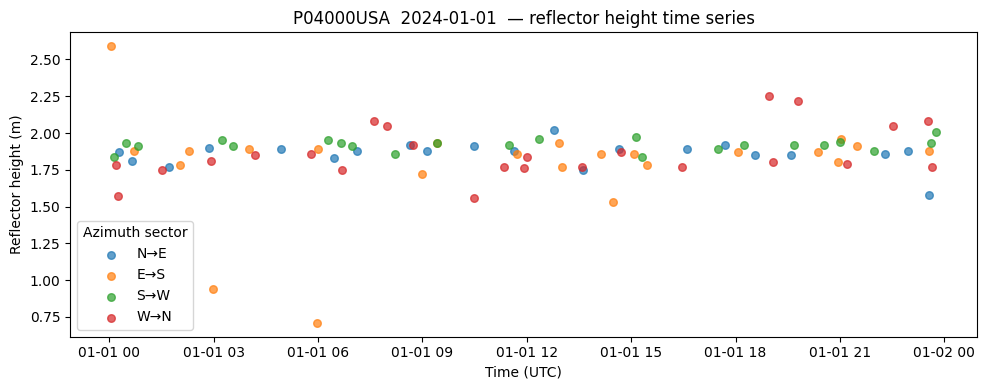

In [44]:
# Single-day time series — median reflector height over the day
# (For multi-day, loop and collect into a list of DataFrames, then pd.concat)

if len(res_df) > 0:
    # Bin by azimuth sector (N/E/S/W)
    bins   = [0, 90, 180, 270, 360]
    labels = ["N→E", "E→S", "S→W", "W→N"]
    res_df["az_sector"] = pd.cut(res_df["azimuth_mean"] % 360, bins=bins, labels=labels, right=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    for sector, grp in res_df.groupby("az_sector", observed=True):
        ax.scatter(grp["t_center"], grp["peak_height"], label=sector, alpha=0.7, s=30)
    ax.set_xlabel("Time (UTC)")
    ax.set_ylabel("Reflector height (m)")
    ax.set_title(f"{STATION}  {DATE}  — reflector height time series")
    ax.legend(title="Azimuth sector")
    plt.tight_layout()
    fig.savefig(FIG_DIR / f"{STATION}_{DATE}_timeseries.png", dpi=200, bbox_inches="tight")
    plt.show()

---

# Single-station deep dive: spectral PDF analysis

Fetch ~90 days of data for one station, compute full Lomb-Scargle periodograms
per arc, and build McNamara-style spectral PDFs (probability density functions)
of the periodogram power. This reveals the station's characteristic reflector
height distribution, multipath environment, and seasonal drift.

In [47]:
from pathlib import Path
from gnss_ir_analysis import analyze_merged_full, IRConfig

FOCUS_STATION = "P04100USA"
DATE_START = dt.date(2024, 1, 1)
DATE_END = dt.date(2024, 3, 31)

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
CACHE_SUMMARY = CACHE_DIR / f"{FOCUS_STATION.lower()}_arcs.parquet"
CACHE_PGRAMS = CACHE_DIR / f"{FOCUS_STATION.lower()}_pgrams.npz"

cfg = IRConfig()

dates = pd.date_range(DATE_START, DATE_END, freq="D").date.tolist()

ref_pt_focus = GeodeticCoordinate(
    latitude=39.9495,
    longitude=-105.1943,
    height=1728.83,
    label=FOCUS_STATION,
)

print(ref_pt_focus)
print(f"{len(dates)} days: {dates[0]} → {dates[-1]}")

latitude=39.9495 longitude=-105.1943 height=1728.83 label='P04100USA'
91 days: 2024-01-01 → 2024-03-31


In [48]:
CACHE_SUMMARY.parent.mkdir(parents=True, exist_ok=True)
if CACHE_SUMMARY.exists() and CACHE_PGRAMS.exists():
    arc_df = pd.read_parquet(CACHE_SUMMARY)
    cached_npz = np.load(CACHE_PGRAMS)
    pgram_matrix = cached_npz["pgrams"]
    heights_grid = cached_npz["heights"]
    print(f"Loaded cache: {len(arc_df):,} arcs, pgram matrix {pgram_matrix.shape}")
else:
    fetch_start = dt.datetime(DATE_START.year, DATE_START.month, DATE_START.day, tzinfo=dt.timezone.utc)
    fetch_end   = dt.datetime(DATE_END.year, DATE_END.month, DATE_END.day, tzinfo=dt.timezone.utc) + dt.timedelta(days=1)

    print(f"Fetching {cfg.sample_interval_s}s SNR observations for {FOCUS_STATION} ...")
    obs_df_focus = client.data.gnss_observations(
        start_datetime=fetch_start,
        end_datetime=fetch_end,
        station_name=FOCUS_STATION,
        system=[cfg.system],
        field="snr",
        obs_code=cfg.obs_code,
        sample_interval=dt.timedelta(seconds=cfg.sample_interval_s),
        session_name="A",
        meta_fields=["igs"],
    ).fetch().to_pandas()
    print(f"  {len(obs_df_focus):,} SNR rows")

    print(f"Fetching {cfg.sample_interval_s}s satellite elevations/azimuths ...")
    eph_df_focus = client.data.gnss_ephemeris_positions(
        start_datetime=fetch_start,
        end_datetime=fetch_end,
        system=[cfg.system],
        field=["elevation", "azimuth"],
        reference_point=ref_pt_focus,
        elevation_filter=FloatFilter(min=cfg.elev_min - 2),
        sample_interval=dt.timedelta(seconds=cfg.sample_interval_s),
    ).fetch().to_pandas()
    print(f"  {len(eph_df_focus):,} ephemeris rows")

    merged_focus = obs_df_focus.merge(
        eph_df_focus.rename(columns={"label": "igs"}),
        on=["timestamp", "system", "satellite", "igs"],
        how="inner",
    ).sort_values(["timestamp", "system", "satellite"]).reset_index(drop=True)
    print(f"Merged: {len(merged_focus):,} rows across {merged_focus['satellite'].nunique()} satellites")

    print(f"Building arcs + periodograms across {len(dates)} days ...")
    arc_df, pgram_matrix, heights_grid = analyze_merged_full(merged_focus, FOCUS_STATION, dates, cfg)

    if not arc_df.empty:
        arc_df.to_parquet(CACHE_SUMMARY, index=False)
        np.savez_compressed(CACHE_PGRAMS, pgrams=pgram_matrix, heights=heights_grid)
        print(f"Done — {len(arc_df):,} arcs over {arc_df['date'].nunique()} days")
    else:
        print("No arcs found — check station/date/system parameters")

print(f"Periodogram matrix: {pgram_matrix.shape}")
arc_df["date"] = pd.to_datetime(arc_df["date"])

Loaded cache: 8,376 arcs, pgram matrix (8376, 990)
Periodogram matrix: (8376, 990)


## 8 · Spectral PDF (McNamara-style)

Each arc's Lomb-Scargle periodogram is one "trace" through height–power space.
Stacking all arcs into a 2D histogram gives the probability density function
of spectral power, analogous to the seismic PSD-PDF of McNamara & Buland (2004).

Rather than keeping just each arc's single best-fit height, this section keeps every arc's full periodogram (power at every candidate height) and stacks hundreds of them into a 2D histogram: height on one axis, power on the other, color showing what fraction of arcs land there. The result is a picture of the station's most common, stable reflector height and how noisy that measurement typically is — the same idea seismologists use to summarize background noise levels (McNamara & Buland's PSD-PDF), just applied to GNSS multipath instead.

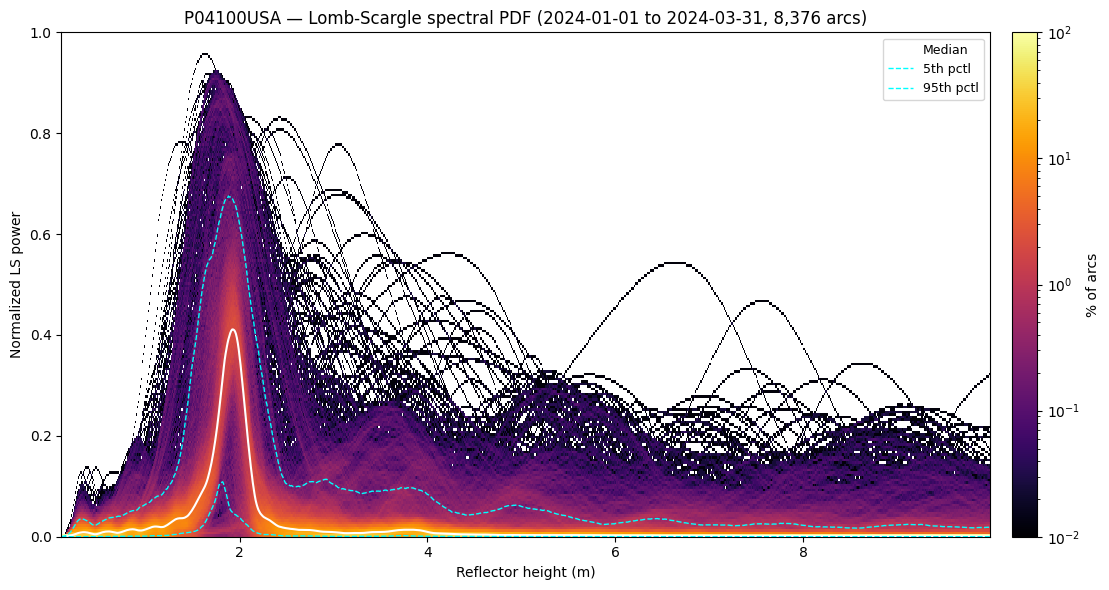

Median peak height: 1.93 m


In [49]:
n_arcs, n_heights = pgram_matrix.shape

power_bins = np.linspace(0, 1.0, 201)
pdf_hist = np.zeros((len(power_bins) - 1, n_heights))

for j in range(n_heights):
    col = pgram_matrix[:, j]
    counts, _ = np.histogram(col, bins=power_bins)
    pdf_hist[:, j] = counts

pdf_prob = pdf_hist / n_arcs * 100  # percentage of arcs in each bin

power_centers = 0.5 * (power_bins[:-1] + power_bins[1:])
median_curve = np.median(pgram_matrix, axis=0)
p05_curve = np.percentile(pgram_matrix, 5, axis=0)
p95_curve = np.percentile(pgram_matrix, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
pdf_plot = np.ma.masked_where(pdf_prob == 0, pdf_prob)
im = ax.pcolormesh(
    heights_grid, power_centers, pdf_plot,
    cmap="inferno",
    norm=plt.matplotlib.colors.LogNorm(vmin=0.01, vmax=pdf_prob.max()),
    shading="nearest",
    rasterized=True,
)
ax.plot(heights_grid, median_curve, color="white", lw=1.5, label="Median")
ax.plot(heights_grid, p05_curve, color="cyan", lw=1, ls="--", label="5th pctl")
ax.plot(heights_grid, p95_curve, color="cyan", lw=1, ls="--", label="95th pctl")

ax.set_xlabel("Reflector height (m)")
ax.set_ylabel("Normalized LS power")
ax.set_title(
    f"{FOCUS_STATION} — Lomb-Scargle spectral PDF "
    f"({arc_df['date'].min().date()} to {arc_df['date'].max().date()}, {n_arcs:,} arcs)"
)
ax.set_xlim(heights_grid[0], heights_grid[-1])
ax.set_ylim(0, min(1.0, p95_curve.max() * 2.5))
ax.legend(loc="upper right", fontsize=9)
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("% of arcs")
plt.tight_layout()
fig.savefig(FIG_DIR / f"{FOCUS_STATION}_spectral_pdf.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Median peak height: {heights_grid[np.argmax(median_curve)]:.2f} m")

## 9 · Polar plot evolution (monthly facets)

Reflector height vs azimuth, faceted by month, showing how the
azimuthal pattern changes over the observation window.

This repeats the azimuth-vs-height polar plot from section 6, but draws one panel per month. Comparing panels side by side shows whether the directional reflector-height pattern is stable over time or shifts — for example, if snow builds up more on one side of the antenna as the season progresses.

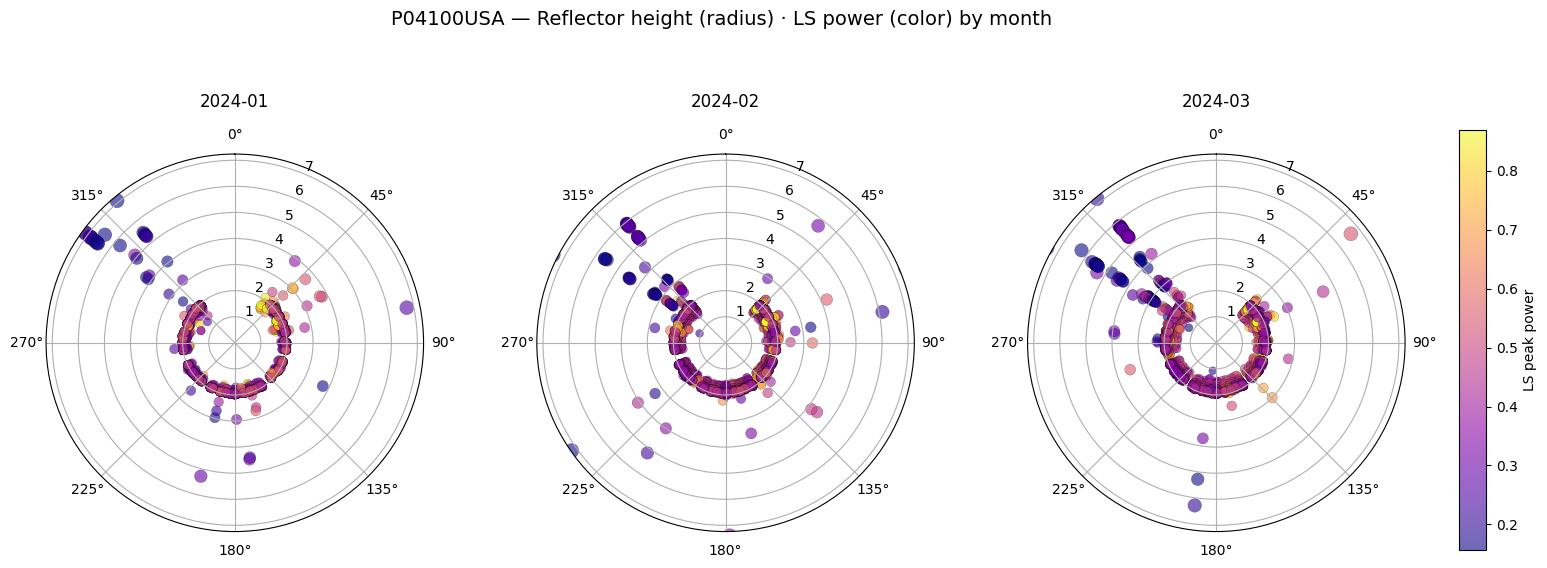

In [50]:
arc_df["month"] = arc_df["date"].dt.to_period("M")
months = sorted(arc_df["month"].unique())
n_months = len(months)

h_global = arc_df["peak_height"].values
h_min_plot, h_max_plot = np.percentile(h_global, [1, 99])
pwr_global = arc_df["peak_power"].values
pwr_min, pwr_max = float(np.percentile(pwr_global, 1)), float(np.percentile(pwr_global, 99))

fig, axes = plt.subplots(
    1, n_months,
    subplot_kw={"projection": "polar"},
    figsize=(6 * n_months, 6),
)
if n_months == 1:
    axes = [axes]

for ax, month in zip(axes, months):
    grp = arc_df[arc_df["month"] == month]
    az_rad = np.radians(grp["azimuth_mean"].values)
    h_vals = grp["peak_height"].values
    pwr    = grp["peak_power"].values

    sc = ax.scatter(
        az_rad, h_vals,
        c=pwr, s=20 + 80 * h_vals / h_max_plot,
        cmap="plasma", vmin=pwr_min, vmax=pwr_max,
        alpha=0.6, edgecolors="k", lw=0.2,
    )
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"{month}", pad=15, fontsize=12)
    ax.set_ylim(0, h_max_plot * 1.1)

fig.suptitle(
    f"{FOCUS_STATION} — Reflector height (radius) · LS power (color) by month",
    fontsize=14, y=1.05,
)
fig.subplots_adjust(right=0.88, wspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("LS peak power")
fig.savefig(FIG_DIR / f"{FOCUS_STATION}_polar_monthly.png", dpi=200, bbox_inches="tight")
plt.show()

## 10 · Time series: daily reflector height & amplitude

This is the full-scale version of section 7: for each day in the ~90-day window, it computes the median reflector height, the median periodogram power, and how many arcs were available, then plots all three over time. This is the main output for tracking gradual surface changes (like seasonal snow accumulation and melt) day by day.

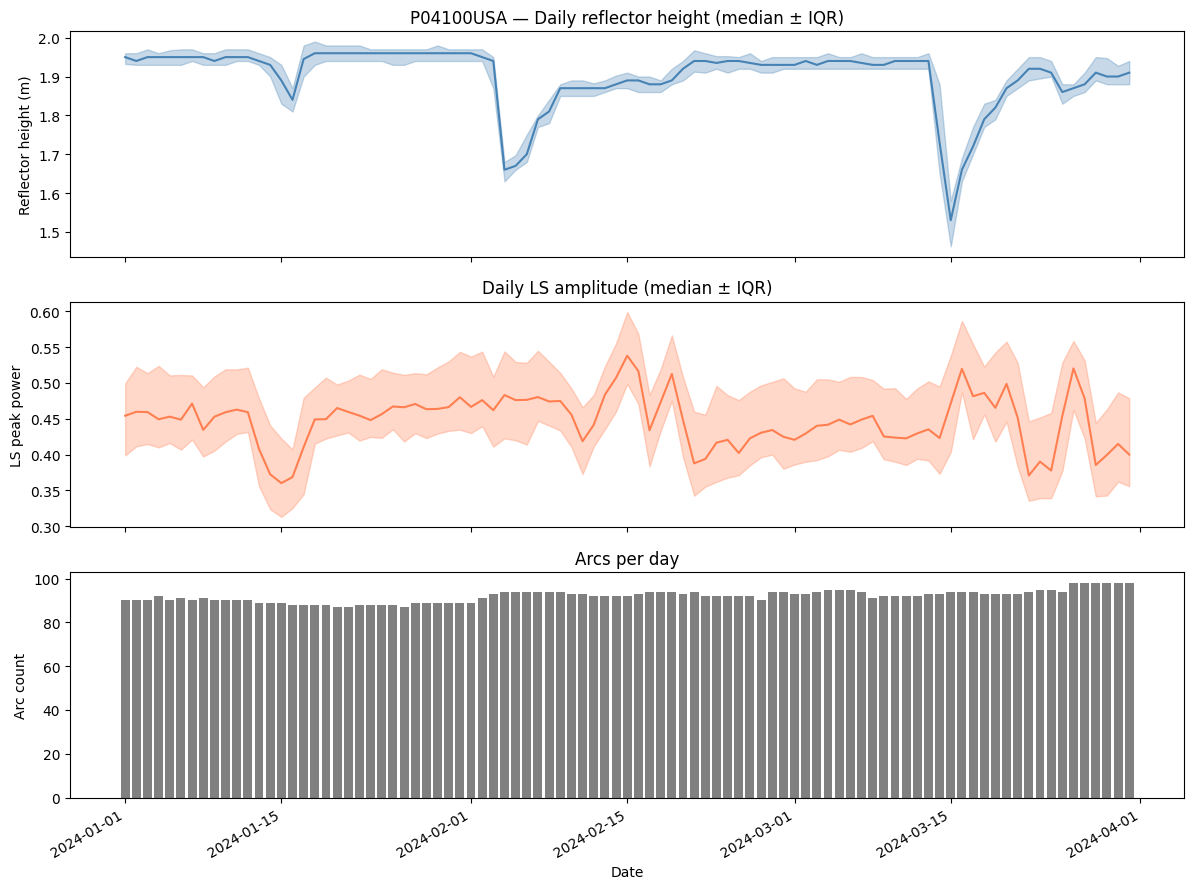

In [51]:
daily = (
    arc_df
    .groupby("date")
    .agg(
        h_median=("peak_height", "median"),
        h_q25=("peak_height", lambda x: np.percentile(x, 25)),
        h_q75=("peak_height", lambda x: np.percentile(x, 75)),
        amp_median=("peak_power", "median"),
        amp_q25=("peak_power", lambda x: np.percentile(x, 25)),
        amp_q75=("peak_power", lambda x: np.percentile(x, 75)),
        n_arcs=("peak_height", "count"),
    )
    .reset_index()
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

ax1.fill_between(daily["date"], daily["h_q25"], daily["h_q75"], alpha=0.3, color="steelblue")
ax1.plot(daily["date"], daily["h_median"], "steelblue", lw=1.5)
ax1.set_ylabel("Reflector height (m)")
ax1.set_title(f"{FOCUS_STATION} — Daily reflector height (median ± IQR)")

ax2.fill_between(daily["date"], daily["amp_q25"], daily["amp_q75"], alpha=0.3, color="coral")
ax2.plot(daily["date"], daily["amp_median"], "coral", lw=1.5)
ax2.set_ylabel("LS peak power")
ax2.set_title("Daily LS amplitude (median ± IQR)")

ax3.bar(daily["date"], daily["n_arcs"], color="0.5", width=0.8)
ax3.set_ylabel("Arc count")
ax3.set_xlabel("Date")
ax3.set_title("Arcs per day")

fig.autofmt_xdate()
plt.tight_layout()
fig.savefig(FIG_DIR / f"{FOCUS_STATION}_daily_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

## 11 · Spectral PDF by azimuth quadrant

Split arcs into N/E/S/W sectors and produce separate spectral PDFs
for each, revealing directional differences in the reflecting surface.

This combines the ideas from sections 8 and 9: it builds the spectral PDF histogram separately for each compass quadrant instead of pooling all arcs together. If the ground surface differs by direction (e.g., a slope on one side, open water on another), each quadrant will show its own characteristic reflector height and noise pattern, making that directional difference explicit.

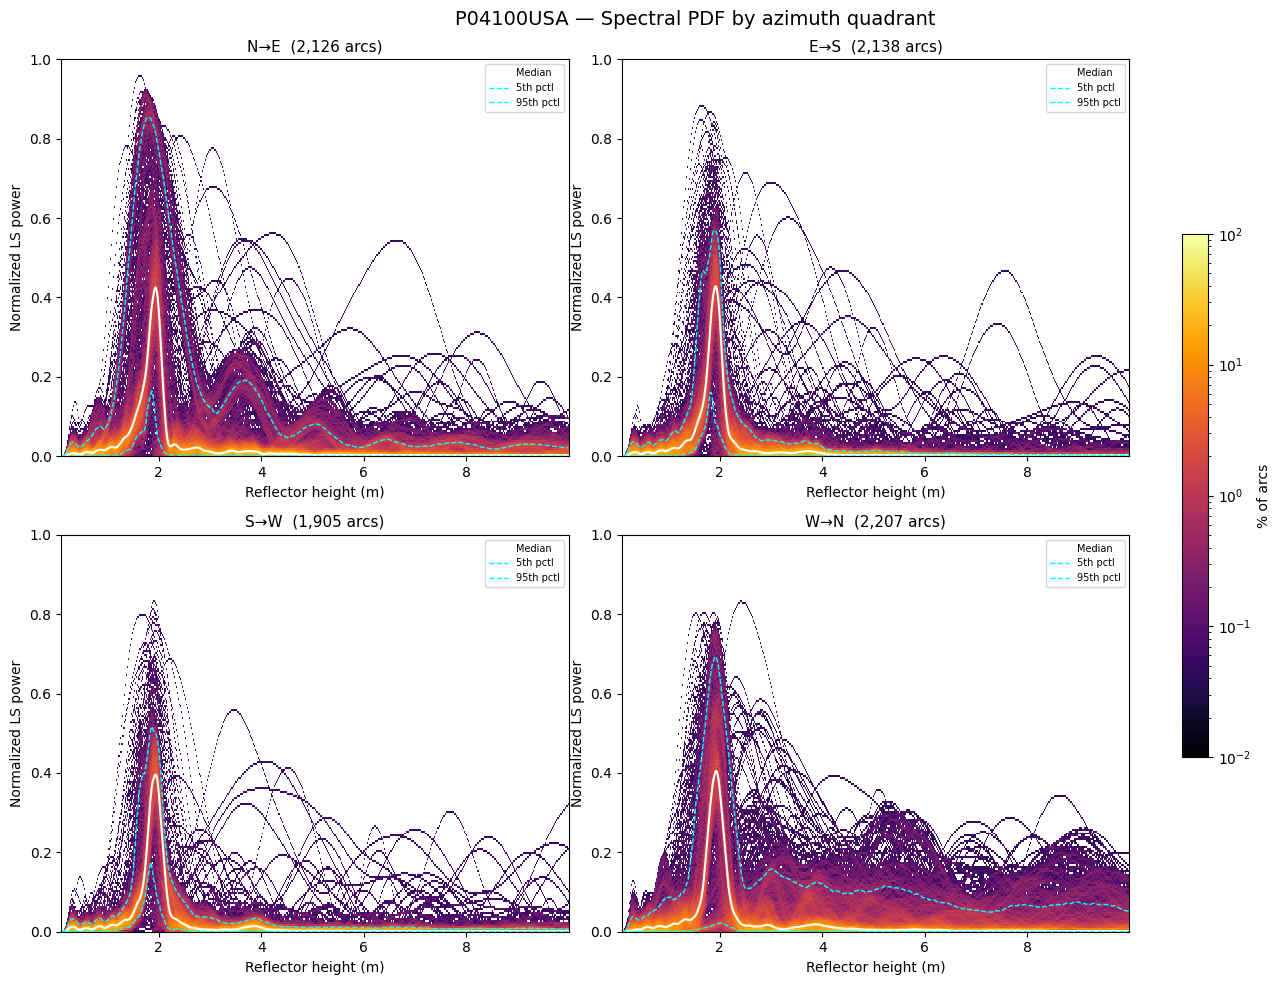

In [52]:
az_bins = [(0, 90, "N→E"), (90, 180, "E→S"), (180, 270, "S→W"), (270, 360, "W→N")]
power_bins_az = np.linspace(0, 1.0, 201)
power_centers_az = 0.5 * (power_bins_az[:-1] + power_bins_az[1:])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (az_lo, az_hi, label) in zip(axes, az_bins):
    mask = (arc_df["azimuth_mean"] >= az_lo) & (arc_df["azimuth_mean"] < az_hi)
    idx = np.where(mask.values)[0]
    n_sect = len(idx)

    if n_sect < 5:
        ax.set_title(f"{label} ({n_sect} arcs — too few)")
        ax.set_visible(False)
        continue

    pgrams_sect = pgram_matrix[idx]
    pdf_sect = np.zeros((len(power_bins_az) - 1, len(heights_grid)))
    for j in range(len(heights_grid)):
        counts, _ = np.histogram(pgrams_sect[:, j], bins=power_bins_az)
        pdf_sect[:, j] = counts
    pdf_sect = pdf_sect / n_sect * 100

    pdf_masked = np.ma.masked_where(pdf_sect == 0, pdf_sect)
    im = ax.pcolormesh(
        heights_grid, power_centers_az, pdf_masked,
        cmap="inferno",
        norm=plt.matplotlib.colors.LogNorm(vmin=0.01, vmax=max(pdf_sect.max(), 0.02)),
        shading="nearest",
        rasterized=True,
    )
    med = np.median(pgrams_sect, axis=0)
    p05 = np.percentile(pgrams_sect, 5, axis=0)
    p95 = np.percentile(pgrams_sect, 95, axis=0)
    ax.plot(heights_grid, med, "w", lw=1.5, label="Median")
    ax.plot(heights_grid, p05, "cyan", lw=1, ls="--", label="5th pctl")
    ax.plot(heights_grid, p95, "cyan", lw=1, ls="--", label="95th pctl")

    ax.set_xlim(heights_grid[0], heights_grid[-1])
    ax.set_ylim(0, min(1.0, p95.max() * 2.5))
    ax.set_title(f"{label}  ({n_sect:,} arcs)", fontsize=11)
    ax.set_xlabel("Reflector height (m)")
    ax.set_ylabel("Normalized LS power")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    f"{FOCUS_STATION} — Spectral PDF by azimuth quadrant",
    fontsize=14,
)
fig.tight_layout()
fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.04, label="% of arcs")
fig.savefig(FIG_DIR / f"{FOCUS_STATION}_spectral_pdf_by_azimuth.png", dpi=200, bbox_inches="tight")
plt.show()